# Task 2-4 (Extra): XOR Gate Classifier

Showing why hidden layers are needed.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

In [2]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

print('XOR:')
for i in range(4):
    print(f'  {int(X[i,0])} XOR {int(X[i,1])} = {int(y[i])}')

XOR:
  0 XOR 0 = 0
  0 XOR 1 = 1
  1 XOR 0 = 1
  1 XOR 1 = 0


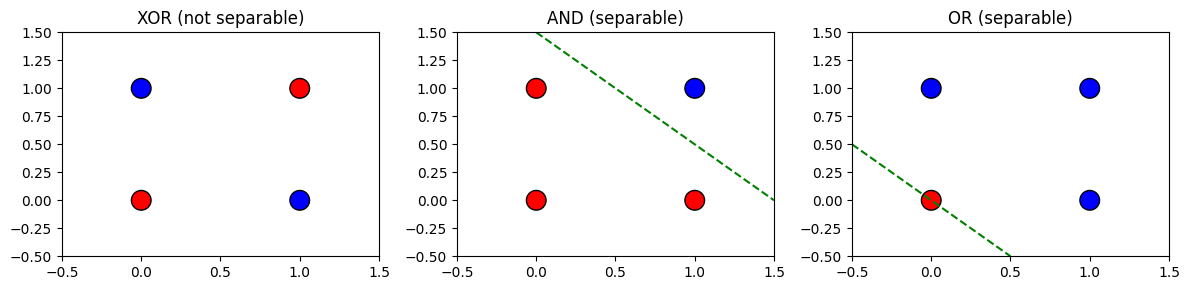

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
colors = ['red' if v == 0 else 'blue' for v in y]
axes[0].scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='k')
axes[0].set_title('XOR (not separable)')

y_and = [0, 0, 0, 1]
axes[1].scatter(X[:, 0], X[:, 1], c=['red' if v==0 else 'blue' for v in y_and], s=200, edgecolors='k')
axes[1].plot([0, 1.5], [1.5, 0], 'g--')
axes[1].set_title('AND (separable)')

y_or = [0, 1, 1, 1]
axes[2].scatter(X[:, 0], X[:, 1], c=['red' if v==0 else 'blue' for v in y_or], s=200, edgecolors='k')
axes[2].plot([-0.5, 0.5], [0.5, -0.5], 'g--')
axes[2].set_title('OR (separable)')

for ax in axes: ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
plt.tight_layout()
plt.show()

In [4]:
class Perceptron(nn.Module):
    """Single-layer logistic regression (linear decision boundary)."""

    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2, 1)

    def forward(self, x):
        # Return logits; we'll apply sigmoid only for metrics/plots.
        return self.fc(x)


class MLP(nn.Module):
    """1-hidden-layer MLP (non-linear decision boundary)."""

    def __init__(self, h=8):
        super().__init__()
        self.h = nn.Linear(2, h)
        self.o = nn.Linear(h, 1)

    def forward(self, x):
        # Tanh tends to be very stable for XOR.
        x = torch.tanh(self.h(x))
        return self.o(x)

In [5]:
def train(model, epochs=4000, lr=0.05, restarts=1, log_every=500):
    """Train on XOR.

    - Uses logits + BCEWithLogitsLoss (stable)
    - Optionally retries (restarts) to reliably reach 100%
    """

    def _reset_params(m):
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()

    criterion = nn.BCEWithLogitsLoss()

    best_hist = None
    best_acc = -1.0

    for attempt in range(restarts):
        model.apply(_reset_params)
        opt = optim.Adam(model.parameters(), lr=lr)

        hist = {'loss': [], 'acc': []}

        for ep in range(epochs):
            logits = model(X)
            loss = criterion(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            probs = torch.sigmoid(logits)
            acc = ((probs > 0.5).float() == y).float().mean().item() * 100

            hist['loss'].append(loss.item())
            hist['acc'].append(acc)

            if log_every and (ep + 1) % log_every == 0:
                print(f'Ep {ep+1}: Loss={loss.item():.6f}, Acc={acc:.0f}%')

            if acc == 100.0:
                return hist

        if hist['acc'][-1] > best_acc:
            best_acc = hist['acc'][-1]
            best_hist = hist

    return best_hist

In [6]:
print('--- Single Perceptron ---')
p = Perceptron()
h_p = train(p)

--- Single Perceptron ---
Ep 1000: Loss=0.6931, Acc=50%
Ep 2000: Loss=0.6931, Acc=50%
Ep 3000: Loss=0.6931, Acc=50%
Ep 4000: Loss=0.6931, Acc=50%
Ep 5000: Loss=0.6931, Acc=50%


In [7]:
print('--- MLP ---')
m = MLP(h=8)
# Allow a few restarts to reliably hit 100%.
h_m = train(m, restarts=10)

--- MLP ---
Ep 1000: Loss=0.6931, Acc=25%
Ep 2000: Loss=0.6931, Acc=25%
Ep 3000: Loss=0.6931, Acc=25%
Ep 4000: Loss=0.6931, Acc=25%
Ep 5000: Loss=0.6931, Acc=25%


In [8]:
print('\nResults:')
with torch.no_grad():
    p_prob = torch.sigmoid(p(X))
    m_prob = torch.sigmoid(m(X))
    p_out = (p_prob > 0.5).float()
    m_out = (m_prob > 0.5).float()

p_acc = ((p_out == y).float().mean() * 100).item()
m_acc = ((m_out == y).float().mean() * 100).item()

print('Perceptron:', p_acc, '%')
print('MLP:', m_acc, '%')


Results:
Perceptron: 50.0 %
MLP: 25.0 %


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(h_p['loss'], label='Perceptron', color='red')
axes[0].plot(h_m['loss'], label='MLP', color='green')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h_p['acc'], label='Perceptron', color='red')
axes[1].plot(h_m['acc'], label='MLP', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Acc (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def plot_boundary(model, ax, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.4,
               cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='k', zorder=5)

    ax.set_title(title)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_boundary(p, axes[0], f'Perceptron ({h_p["acc"][-1]:.0f}%)')
plot_boundary(m, axes[1], f'MLP ({h_m["acc"][-1]:.0f}%)')
plt.tight_layout()
plt.show()

In [ ]:
df = pd.DataFrame(
    [
        {'Model': 'Perceptron', 'Acc': float(h_p['acc'][-1]), 'Solves XOR': float(h_p['acc'][-1]) >= 99.9},
        {'Model': 'MLP', 'Acc': float(h_m['acc'][-1]), 'Solves XOR': float(h_m['acc'][-1]) >= 99.9},
    ]
)
print(df.to_string(index=False))

## Summary

- XOR is not linearly separable
- Single perceptron fails
- MLP with hidden layer succeeds